# Intraday Features — Hourly Sentiment & Volume Patterns

Computes intraday (within-day) features from social media data with exact timestamps.

## Motivation

Polymarket prices are scraped once per day at ~00:03 UTC.  A daily-resolution model
therefore cannot capture *same-day* events — by midnight the market has already
reacted.  However, the *pattern within a day* can still help predict the **next
day's** price change:

- **Sentiment acceleration**: if Trump sentiment rises from morning to evening,
  that positive momentum may not be fully priced in by midnight → predicts a
  positive change the next day.
- **Volume bursts**: an unusually high post count in a single hour is a proxy
  for breaking news.  Even if the market starts to react, full repricing may
  take until the next day.
- **Morning vs evening lead/lag**: US East Coast traders are most active in the
  afternoon/evening UTC (roughly 12:00–23:00 UTC = 08:00–19:00 ET).  Morning UTC
  posts (European/overnight) may lead price discovery.

## Data leakage note

All intraday features are computed for calendar day **t** (UTC).
When they are used in the predictive models they are **shifted by 1 day**
(i.e. day-t features predict day-t+1 price change) — this shift is applied
explicitly in `basetable_v2.ipynb`, NOT here.

## Sources
- **Bluesky** (`Data/2_Silver/Bluesky/bsky_US_2024_posts.csv`):
  exact UTC timestamps + pre-labelled `candidate` column (CandidateA=Trump,
  CandidateB=Harris, Neutral).
- **Reddit** (`Data/1_Bronze/Reddit/r_*.jsonl`):
  `created_utc` Unix timestamps + `title` text → VADER sentiment.

## Output
`Data/3_Gold/intraday_features.csv` — one row per calendar day, one feature per column.


## Setup

In [1]:
import sys, os, json as _json, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('../..'))
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
vader = SentimentIntensityAnalyzer()

from Descriptive.house_style import (apply_style, styled_fig, style_ax,
    BG_DARK, BG_PANEL, TEXT_PRIMARY, TEXT_MUTED, GRID_COLOR, SPINE_COLOR,
    REPUBLICAN, DEMOCRAT, NEUTRAL, PALETTE)
apply_style()
print("Setup OK — VADER loaded")

Setup OK — VADER loaded


## Bluesky — load & parse timestamps

In [2]:
# Load the Silver Bluesky CSV.
# The `candidate` column is already labelled:
#   CandidateA = Trump-related hashtag cluster
#   CandidateB = Harris-related hashtag cluster
#   Neutral    = general election buzz
# Note: a "CandidateA" post was found via a Trump hashtag but may be pro- or anti-Trump.
# We use VADER on the post text to get the actual sentiment polarity.

bsky = pd.read_csv('../../Data/2_Silver/Bluesky/bsky_US_2024_posts.csv',
                   usecols=['timestamp', 'candidate', 'text'])

# Parse UTC timestamps — keep timezone-aware, then normalize to date
bsky['dt_utc'] = pd.to_datetime(bsky['timestamp'], format='ISO8601', utc=True)
bsky['date']   = bsky['dt_utc'].dt.normalize().dt.tz_localize(None)
bsky['hour']   = bsky['dt_utc'].dt.hour  # 0–23 UTC

# Time-of-day bucket: morning = 00:00–11:59 UTC, evening = 12:00–23:59 UTC
# Rationale: East Coast US is UTC-4 (EDT) or UTC-5 (EST).
#   morning UTC  ≈ overnight + early morning ET (quiet period)
#   evening UTC  ≈ East Coast afternoon + evening (high-activity period)
bsky['period'] = bsky['hour'].apply(lambda h: 'morning' if h < 12 else 'evening')

# Compute VADER compound sentiment per post
# compound ∈ [-1, 1]:  > 0.05 positive, < -0.05 negative, else neutral
print("Computing VADER sentiment on Bluesky posts (this takes ~1-2 min)...")
bsky['compound'] = bsky['text'].fillna('').apply(
    lambda t: vader.polarity_scores(t)['compound'])

print(f"Bluesky posts loaded: {len(bsky):,}")
print(f"Date range: {bsky['date'].min().date()} -> {bsky['date'].max().date()}")
print(f"Candidate distribution:")
print(bsky['candidate'].value_counts().to_string())

Computing VADER sentiment on Bluesky posts (this takes ~1-2 min)...


Bluesky posts loaded: 27,215
Date range: 2024-07-05 -> 2024-11-04
Candidate distribution:
candidate
CandidateA    11749
Neutral        9532
CandidateB     5934


## Bluesky — compute intraday features

In [3]:
# ── Per-day intraday aggregations ─────────────────────────────────────────────
#
# For each calendar day we compute:
#
# 1. MORNING vs EVENING SENTIMENT (per candidate cluster)
#    — Did Trump/Harris sentiment build or decay during the day?
#    — If evening > morning (positive acceleration), the mood was strengthening
#      toward the end of the day; this may not be fully priced yet at midnight.
#
# 2. SENTIMENT ACCELERATION = evening_sentiment - morning_sentiment
#    — The sign tells us the direction of intraday momentum.
#    — A large positive value for Trump = Trump sentiment was rising all day.
#
# 3. RELATIVE ACCELERATION = (trump_accel) - (harris_accel)
#    — Did Trump sentiment strengthen MORE than Harris sentiment during the day?
#
# 4. VOLUME BURST = max_hourly_count / mean_hourly_count
#    — A ratio >> 1 means one hour dominated (proxy for breaking news).
#    — Computed on all posts regardless of candidate.

records = []
for date, day_df in bsky.groupby('date'):
    row = {'date': date}

    for cand, cprefix in [('CandidateA', 'bsky_trump'), ('CandidateB', 'bsky_harris')]:
        cdf = day_df[day_df['candidate'] == cand]

        for period in ['morning', 'evening']:
            pdf = cdf[cdf['period'] == period]
            row[f'{cprefix}_{period}_sent'] = (pdf['compound'].mean()
                                               if len(pdf) >= 3 else np.nan)

        # Acceleration = evening sentiment minus morning sentiment
        m = row.get(f'{cprefix}_morning_sent', np.nan)
        e = row.get(f'{cprefix}_evening_sent', np.nan)
        row[f'{cprefix}_sent_accel'] = (e - m
                                        if not (np.isnan(m) or np.isnan(e))
                                        else np.nan)

    # Relative acceleration: does Trump sentiment strengthen vs Harris during the day?
    ta = row.get('bsky_trump_sent_accel', np.nan)
    ha = row.get('bsky_harris_sent_accel', np.nan)
    row['bsky_relative_sent_accel'] = (ta - ha
                                       if not (np.isnan(ta) or np.isnan(ha))
                                       else np.nan)

    # Volume burst: how concentrated is posting activity in a single hour?
    hourly_counts = day_df.groupby('hour').size()
    if len(hourly_counts) >= 4:
        row['bsky_volume_burst'] = hourly_counts.max() / hourly_counts.mean()
    else:
        row['bsky_volume_burst'] = np.nan

    records.append(row)

bsky_intraday = pd.DataFrame(records)
print(f"Bluesky intraday features: {bsky_intraday.shape}")
print()
print("NaN counts per column:")
print(bsky_intraday.isnull().sum().to_string())

Bluesky intraday features: (123, 9)

NaN counts per column:
date                         0
bsky_trump_morning_sent      1
bsky_trump_evening_sent      0
bsky_trump_sent_accel        1
bsky_harris_morning_sent    11
bsky_harris_evening_sent     0
bsky_harris_sent_accel      11
bsky_relative_sent_accel    12
bsky_volume_burst            0


## Reddit — load & parse timestamps

In [4]:
# Load all Reddit post JSONL files.
# We use the `title` field (short, headline-like) for VADER sentiment.
# `created_utc` is a Unix timestamp in seconds (UTC).

REDDIT_FILES = [
    '../../Data/1_Bronze/Reddit/r_politics_posts.jsonl',
    '../../Data/1_Bronze/Reddit/r_conservative_posts.jsonl',
    '../../Data/1_Bronze/Reddit/r_worldnews_posts.jsonl',
]
TRUMP_KW  = {'trump', 'donald', 'maga', 'republican', 'gop'}
HARRIS_KW = {'harris', 'kamala', 'democrat', 'walz', 'democratic'}

rows = []
for path in REDDIT_FILES:
    sub = os.path.basename(path).replace('_posts.jsonl', '')
    with open(path, encoding='utf-8') as fh:
        for line in fh:
            d = _json.loads(line)
            rows.append({
                'title':       d.get('title', ''),
                'created_utc': d.get('created_utc') or d.get('created', 0),
                'subreddit':   sub,
                'score':       d.get('score', 0),
            })

reddit = pd.DataFrame(rows)
reddit['dt_utc'] = pd.to_datetime(reddit['created_utc'], unit='s', utc=True)
reddit['date']   = reddit['dt_utc'].dt.normalize().dt.tz_localize(None)
reddit['hour']   = reddit['dt_utc'].dt.hour
reddit['period'] = reddit['hour'].apply(lambda h: 'morning' if h < 12 else 'evening')

# Label each post as trump-related / harris-related / neither based on title keywords
def label_post(title):
    t = title.lower()
    is_trump  = any(k in t for k in TRUMP_KW)
    is_harris = any(k in t for k in HARRIS_KW)
    if is_trump and not is_harris:  return 'trump'
    if is_harris and not is_trump:  return 'harris'
    if is_trump and is_harris:      return 'both'
    return 'neither'

reddit['candidate'] = reddit['title'].apply(label_post)

print("Computing VADER sentiment on Reddit titles...")
reddit['compound'] = reddit['title'].fillna('').apply(
    lambda t: vader.polarity_scores(t)['compound'])

print(f"Reddit posts loaded: {len(reddit):,}")
print(f"Date range: {reddit['date'].min().date()} -> {reddit['date'].max().date()}")
print(f"Candidate labels:")
print(reddit['candidate'].value_counts().to_string())

Computing VADER sentiment on Reddit titles...


Reddit posts loaded: 148,607
Date range: 2024-07-04 -> 2024-11-03
Candidate labels:
candidate
neither    88468
trump      30634
harris     19676
both        9829


## Reddit — compute intraday features

In [5]:
# Same logic as Bluesky: morning vs evening VADER sentiment + acceleration + burst.
# Reddit titles are shorter and more news-headline-like than Bluesky posts,
# so they may capture breaking news events more cleanly.

records_r = []
for date, day_df in reddit.groupby('date'):
    row = {'date': date}

    for cand, cprefix in [('trump', 'reddit_trump'), ('harris', 'reddit_harris')]:
        cdf = day_df[day_df['candidate'] == cand]
        for period in ['morning', 'evening']:
            pdf = cdf[cdf['period'] == period]
            row[f'{cprefix}_{period}_sent'] = (pdf['compound'].mean()
                                               if len(pdf) >= 3 else np.nan)
        m = row.get(f'{cprefix}_morning_sent', np.nan)
        e = row.get(f'{cprefix}_evening_sent', np.nan)
        row[f'{cprefix}_sent_accel'] = (e - m
                                        if not (np.isnan(m) or np.isnan(e))
                                        else np.nan)

    ta = row.get('reddit_trump_sent_accel', np.nan)
    ha = row.get('reddit_harris_sent_accel', np.nan)
    row['reddit_relative_sent_accel'] = (ta - ha
                                         if not (np.isnan(ta) or np.isnan(ha))
                                         else np.nan)

    hourly = day_df.groupby('hour').size()
    row['reddit_volume_burst'] = hourly.max() / hourly.mean() if len(hourly) >= 4 else np.nan

    records_r.append(row)

reddit_intraday = pd.DataFrame(records_r)
print(f"Reddit intraday features: {reddit_intraday.shape}")
print()
print("NaN counts per column:")
print(reddit_intraday.isnull().sum().to_string())

Reddit intraday features: (123, 9)

NaN counts per column:
date                          0
reddit_trump_morning_sent     0
reddit_trump_evening_sent     0
reddit_trump_sent_accel       0
reddit_harris_morning_sent    0
reddit_harris_evening_sent    0
reddit_harris_sent_accel      0
reddit_relative_sent_accel    0
reddit_volume_burst           0


## Merge & exploratory plots

Intraday features shape: (124, 17)
Columns: ['date', 'bsky_trump_morning_sent', 'bsky_trump_evening_sent', 'bsky_trump_sent_accel', 'bsky_harris_morning_sent', 'bsky_harris_evening_sent', 'bsky_harris_sent_accel', 'bsky_relative_sent_accel', 'bsky_volume_burst', 'reddit_trump_morning_sent', 'reddit_trump_evening_sent', 'reddit_trump_sent_accel', 'reddit_harris_morning_sent', 'reddit_harris_evening_sent', 'reddit_harris_sent_accel', 'reddit_relative_sent_accel', 'reddit_volume_burst']

NaN fraction per column:
date                           0.0
bsky_trump_morning_sent        1.6
bsky_trump_evening_sent        0.8
bsky_trump_sent_accel          1.6
bsky_harris_morning_sent       9.7
bsky_harris_evening_sent       0.8
bsky_harris_sent_accel         9.7
bsky_relative_sent_accel      10.5
bsky_volume_burst              0.8
reddit_trump_morning_sent      1.6
reddit_trump_evening_sent      1.6
reddit_trump_sent_accel        1.6
reddit_harris_morning_sent     1.6
reddit_harris_evening_sent    

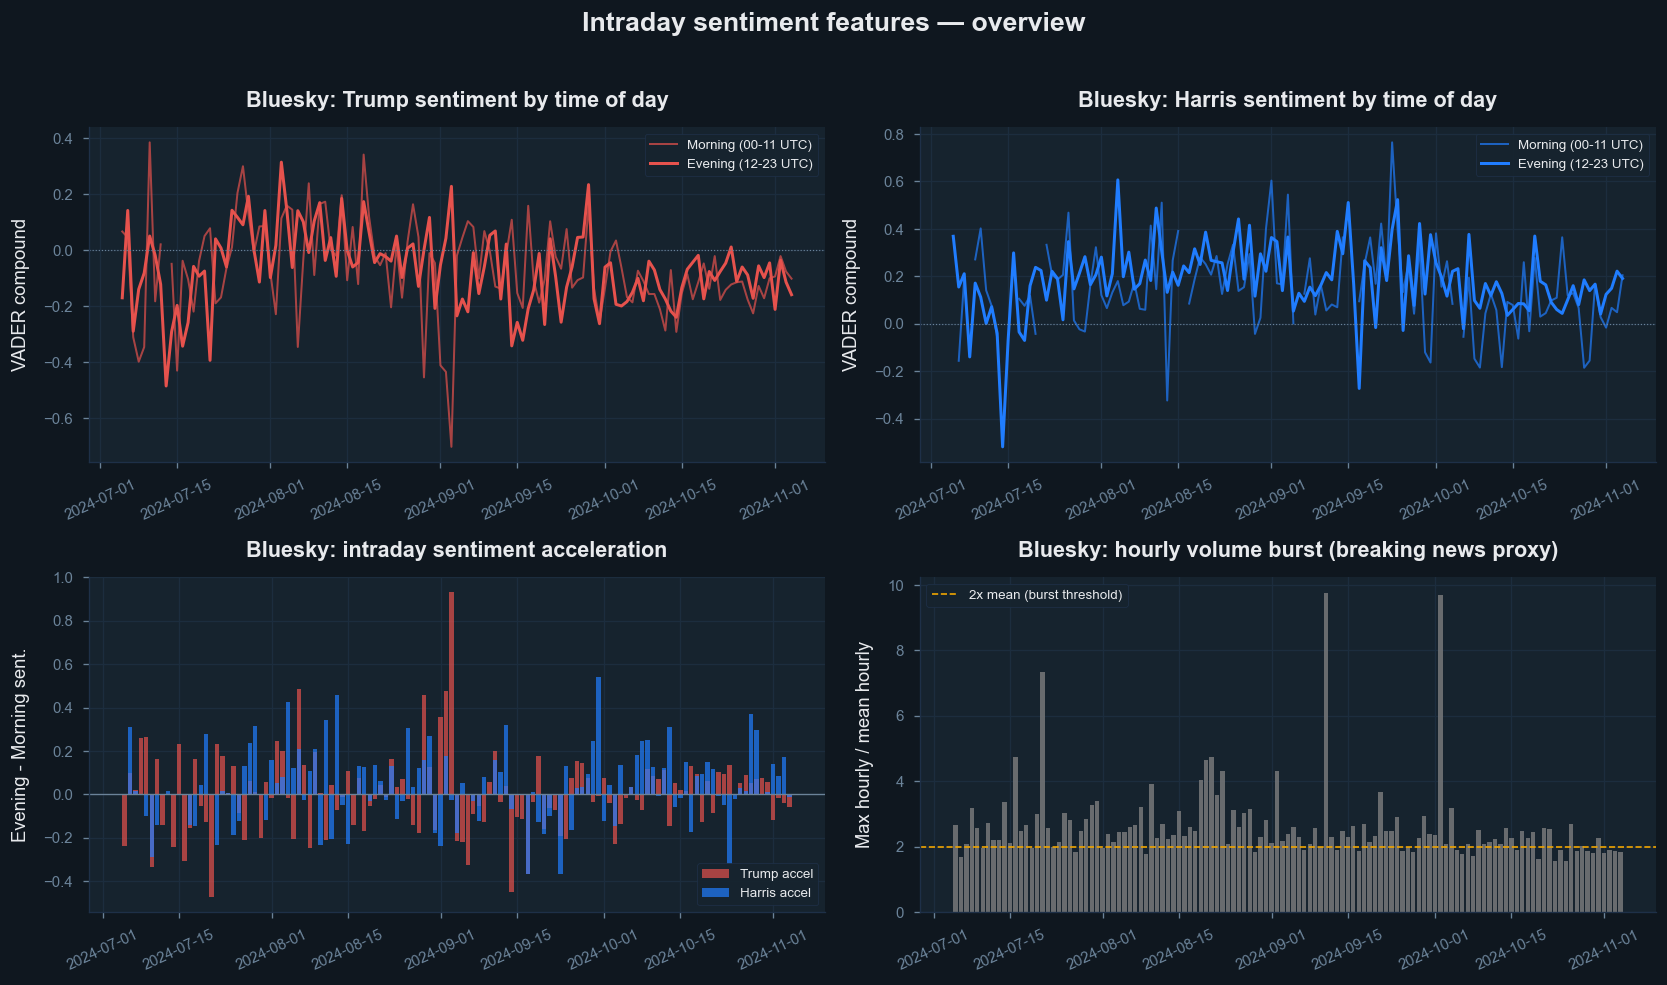

In [6]:
# Merge Bluesky and Reddit intraday features on date.
# Load the basetable date range to align correctly.
basetable = pd.read_csv('../../Data/3_Gold/basetable.csv', parse_dates=['date'])
date_range = pd.DataFrame({'date': basetable['date'].sort_values().values})

intraday = (date_range
            .merge(bsky_intraday,   on='date', how='left')
            .merge(reddit_intraday, on='date', how='left'))

print(f"Intraday features shape: {intraday.shape}")
print(f"Columns: {list(intraday.columns)}")
print()
print(f"NaN fraction per column:")
print((intraday.isnull().mean() * 100).round(1).to_string())

# ── Plot 1: Bluesky sentiment acceleration over time ──────────────────────────
fig, axes = styled_fig(2, 2, figsize=(14, 8),
    title="Intraday sentiment features — overview")
ax1, ax2, ax3, ax4 = axes.flat

# Trump sentiment: morning vs evening
ax1.plot(intraday['date'], intraday['bsky_trump_morning_sent'],
         color=REPUBLICAN, lw=1.2, alpha=0.7, label='Morning (00-11 UTC)')
ax1.plot(intraday['date'], intraday['bsky_trump_evening_sent'],
         color=REPUBLICAN, lw=1.8, label='Evening (12-23 UTC)')
ax1.axhline(0, color=TEXT_MUTED, lw=0.7, ls=':')
style_ax(ax1, ylabel='VADER compound', title='Bluesky: Trump sentiment by time of day')
ax1.legend(fontsize=8)

# Harris sentiment: morning vs evening
ax2.plot(intraday['date'], intraday['bsky_harris_morning_sent'],
         color=DEMOCRAT, lw=1.2, alpha=0.7, label='Morning (00-11 UTC)')
ax2.plot(intraday['date'], intraday['bsky_harris_evening_sent'],
         color=DEMOCRAT, lw=1.8, label='Evening (12-23 UTC)')
ax2.axhline(0, color=TEXT_MUTED, lw=0.7, ls=':')
style_ax(ax2, ylabel='VADER compound', title='Bluesky: Harris sentiment by time of day')
ax2.legend(fontsize=8)

# Sentiment acceleration
ax3.bar(intraday['date'], intraday['bsky_trump_sent_accel'],
        color=REPUBLICAN, alpha=0.7, width=0.8, label='Trump accel')
ax3.bar(intraday['date'], intraday['bsky_harris_sent_accel'],
        color=DEMOCRAT, alpha=0.7, width=0.8, label='Harris accel')
ax3.axhline(0, color=TEXT_MUTED, lw=0.8)
style_ax(ax3, ylabel='Evening - Morning sent.', title='Bluesky: intraday sentiment acceleration')
ax3.legend(fontsize=8)

# Volume burst
ax4.bar(intraday['date'], intraday['bsky_volume_burst'],
        color=NEUTRAL, alpha=0.85, width=0.8)
ax4.axhline(2, color='#f0a500', lw=1, ls='--', label='2x mean (burst threshold)')
style_ax(ax4, ylabel='Max hourly / mean hourly',
         title='Bluesky: hourly volume burst (breaking news proxy)')
ax4.legend(fontsize=8)

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

## Correlation with next-day price change

Pearson correlation with next-day price change (features shifted by 1 day):

reddit_trump_morning_sent     0.1884
reddit_trump_sent_accel      -0.1136
reddit_trump_evening_sent     0.1039
bsky_harris_sent_accel        0.0765
reddit_relative_sent_accel   -0.0741
bsky_trump_morning_sent      -0.0699
bsky_trump_evening_sent      -0.0582
bsky_harris_morning_sent     -0.0553
bsky_volume_burst            -0.0517
reddit_harris_evening_sent    0.0405
bsky_trump_sent_accel         0.0393
reddit_volume_burst           0.0315
reddit_harris_morning_sent    0.0233
bsky_relative_sent_accel     -0.0155
bsky_harris_evening_sent      0.0118
reddit_harris_sent_accel      0.0031


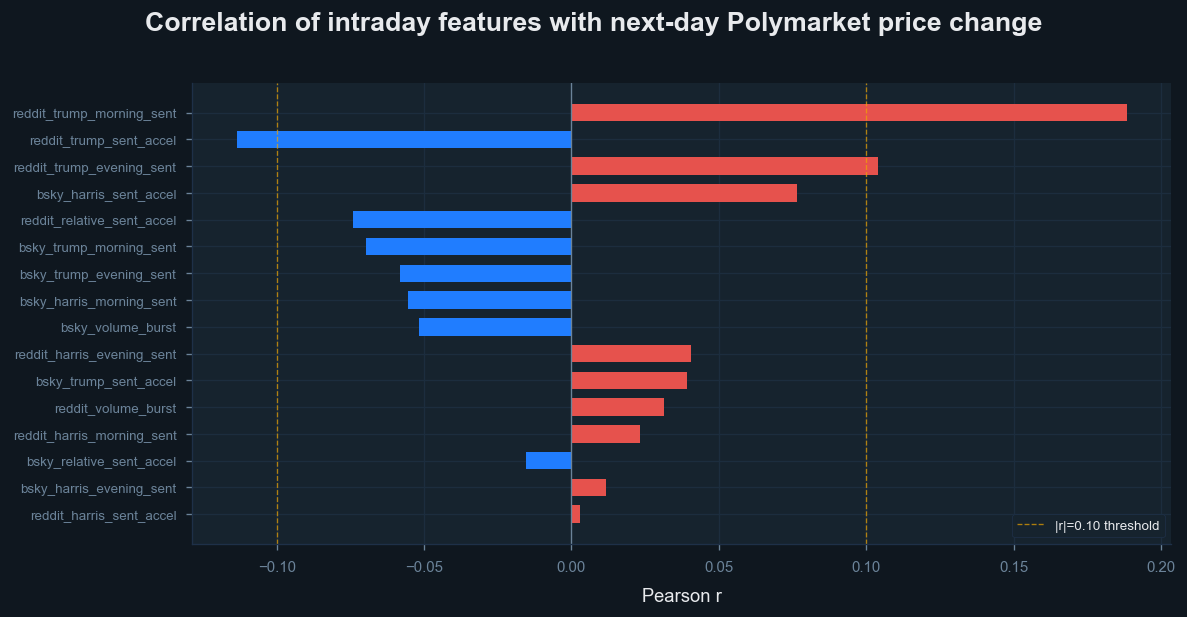

In [7]:
# Join intraday features with the price change target to check predictive signal.
# IMPORTANT: we shift intraday features by 1 day here ONLY for the correlation check.
# The actual shift will be applied in basetable_v2.ipynb.
#
# Interpretation:
#   A positive correlation between bsky_trump_sent_accel (day t)
#   and price_change (day t+1) means: when Trump Bluesky sentiment
#   was rising during the day, the Polymarket price tended to rise next day.

bt = basetable[['date', 'polymarket_trump_prob']].copy()
bt['price_change'] = bt['polymarket_trump_prob'].diff()  # change on day t

# Shift intraday features by 1 so they predict next-day change
intraday_lag = intraday.copy()
feat_cols = [c for c in intraday.columns if c != 'date']
intraday_lag[feat_cols] = intraday_lag[feat_cols].shift(1)

merged = bt.merge(intraday_lag, on='date', how='left').dropna(subset=['price_change'])

corrs = merged[feat_cols].corrwith(merged['price_change']).sort_values(key=abs, ascending=False)
print("Pearson correlation with next-day price change (features shifted by 1 day):")
print()
print(corrs.round(4).to_string())

# Bar chart of correlations
fig, ax = styled_fig(1, 1, figsize=(10, 5),
    title="Correlation of intraday features with next-day Polymarket price change")
colors_c = [REPUBLICAN if v > 0 else DEMOCRAT for v in corrs.values]
ax.barh(range(len(corrs)), corrs.values[::-1], color=colors_c[::-1], height=0.65)
ax.set_yticks(range(len(corrs)))
ax.set_yticklabels(corrs.index[::-1], fontsize=8, color=TEXT_PRIMARY)
ax.axvline(0, color=TEXT_MUTED, lw=0.8)
ax.axvline( 0.1, color='#f0a500', lw=0.8, ls='--', alpha=0.7)
ax.axvline(-0.1, color='#f0a500', lw=0.8, ls='--', alpha=0.7, label='|r|=0.10 threshold')
style_ax(ax, xlabel='Pearson r', grid_axis='x')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Save

In [8]:
# Save the RAW intraday features (NOT shifted).
# The shift(1) is applied in basetable_v2.ipynb so it is explicit and documented.
OUT = '../../Data/3_Gold/intraday_features.csv'
intraday.to_csv(OUT, index=False)
print(f"Saved: {OUT}")
print(f"Shape: {intraday.shape}")
print(f"Columns: {list(intraday.columns)}")
print()
print("Next step: run basetable_v2.ipynb to merge with basetable and apply shift(1).")

Saved: ../../Data/3_Gold/intraday_features.csv
Shape: (124, 17)
Columns: ['date', 'bsky_trump_morning_sent', 'bsky_trump_evening_sent', 'bsky_trump_sent_accel', 'bsky_harris_morning_sent', 'bsky_harris_evening_sent', 'bsky_harris_sent_accel', 'bsky_relative_sent_accel', 'bsky_volume_burst', 'reddit_trump_morning_sent', 'reddit_trump_evening_sent', 'reddit_trump_sent_accel', 'reddit_harris_morning_sent', 'reddit_harris_evening_sent', 'reddit_harris_sent_accel', 'reddit_relative_sent_accel', 'reddit_volume_burst']

Next step: run basetable_v2.ipynb to merge with basetable and apply shift(1).
